## Importing Required Libraries

In this step, we import the libraries needed for the project. These libraries help us load the dataset, preprocess the features, and visualize the data. Together, they provide the essential tools for performing clustering and analyzing the results.

In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Loading the Iris Dataset

We load the **Iris dataset**, one of the most widely used datasets in machine learning. It contains measurements of iris flowers from three different species. The feature matrix (`X`) stores the input features, while the target variable (`y`) contains the corresponding species labels.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

## Feature Scaling

Before applying the clustering algorithm, we standardize the features using **StandardScaler**. This ensures that all features are on the same scale, preventing variables with larger values from having a greater influence on the clustering results.

In [3]:
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualizing the Dataset

Before applying the clustering algorithm, we visualize the standardized dataset using a scatter plot. This helps us observe the distribution of the data points and identify any natural grouping or separation that may exist between them.

<Axes: >

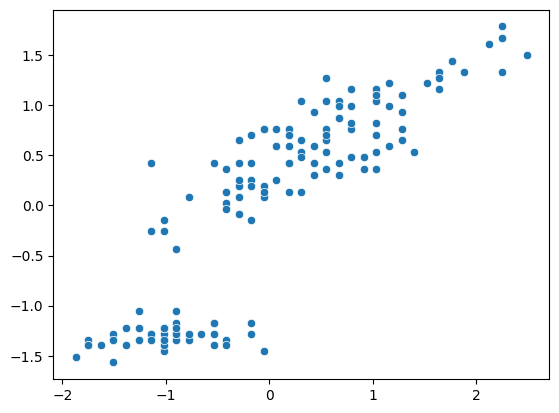

In [4]:
# visualize
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2])

## Building the Dendrogram

A **dendrogram** is a tree-like diagram used in Hierarchical Clustering to visualize how data points are merged into clusters. It helps us understand the hierarchical relationships between samples and estimate the optimal number of clusters by observing the largest vertical gaps before merges occur.

Text(0.5, 1.0, 'Dendrogram for hierarchical clustering')

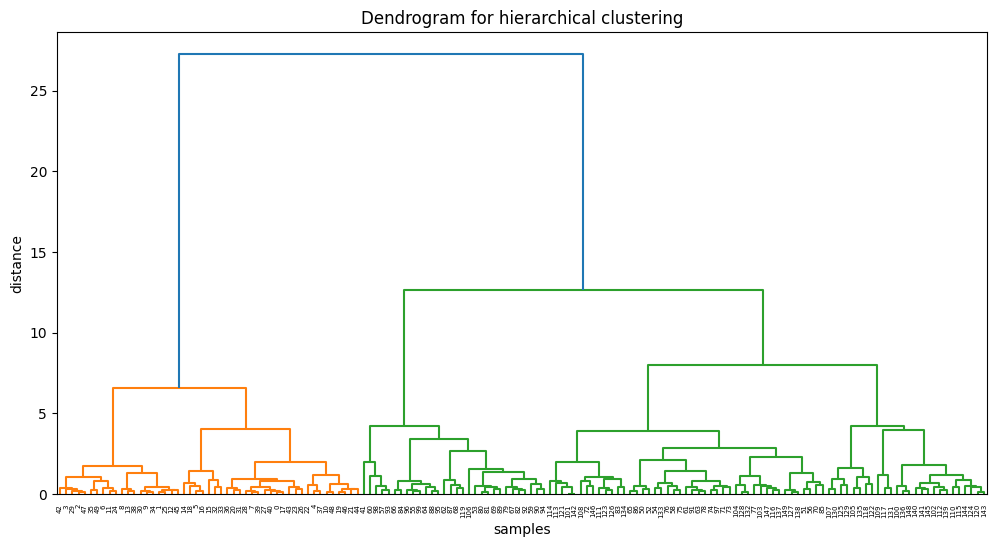

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram

# linkage matrix
Z = linkage(X_scaled, method="ward")

# Plot
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.xlabel("samples")
plt.ylabel("distance")
plt.title("Dendrogram for hierarchical clustering")

## Applying Agglomerative Hierarchical Clustering

In this step, we apply the **Agglomerative Clustering** algorithm to the standardized dataset. The algorithm starts by treating each data point as an individual cluster and then repeatedly merges the closest clusters until the specified number of clusters is reached. Here, we set **`n_clusters=3`** to partition the dataset into three clusters.

In [6]:
# Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_scaled)

## Visualizing the Hierarchical Clusters

The scatter plot displays the clusters formed by the **Agglomerative Hierarchical Clustering** algorithm. Each color represents a different cluster, allowing us to observe how similar data points have been grouped based on their feature values.

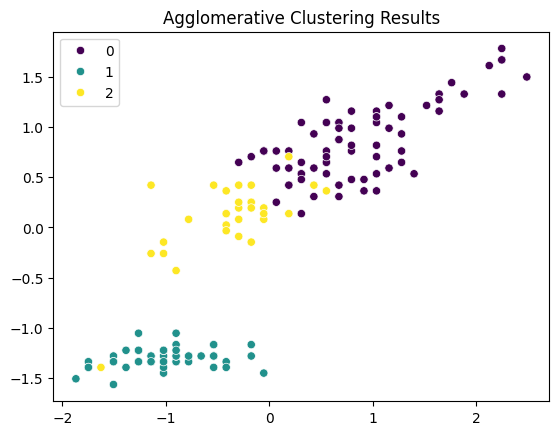

In [7]:
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 2], hue=labels, palette="viridis")
plt.title("Agglomerative Clustering Results")
plt.show()